In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from my_fun.my_fun import fig_size, save_notebook_files
from analysis import *

In [6]:
# Magics
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'png'
# %config InlineBackend.figure_format = 'retina'

# Load example session

In [8]:
subject = '007'
ephys_id = '007_2024-06-24_17-47-22'
preprocessed = preprocess(ephys_id)
cluster_info = preprocessed.cluster_info
# df_spikes = preprocessed.df_spikes
# df_ttl = preprocessed.df_ttl
df_behavior = preprocessed.df_behavior
# disengagement = find_disengaged(df_behavior, threshold=0.5, min_trial=200, win_len=20, plot=False)

Development mode: remote (minibaps, alexis, Linux)

Processor ID: 109, Stream Name: ProbeA-AP, Line: 1 (main sync line))
  First event sample number: 59449398
  Last event sample number: 230358711
  Total sync events: 6000
  Sample rate: 30000.0
Processor ID: 109, Stream Name: ProbeA-LFP, Line: 1 (aux sync line))
  First event sample number: 4954116
  Last event sample number: 19196559
  Total sync events: 4763
  Scale factor: 11.99999978936198
  Actual sample rate: 2500.0000438829215


Development mode: remote (minibaps, alexis, Linux)

All sounds sent by Bpod match those received by Arduino
There is(are) 1 more ephys trial(s) than behavior trial(s)
999 trials common to both data sources. Using it for later slicing
All sounds from behavior and ephys match


Min spike time: 0 min
Max spike time: 126 min


The aquisition (press PLAY in Open Ephys) started at 0 min and ended after 144 min. It includes the time for lowering the probe.
The recording (press REC in Open Ephys) started at 18 

In [14]:
session = df_behavior.Session.unique()
experiment = df_behavior.Experiment.unique()

In [10]:
align = 'stim'
folder_parent = Path.home() / 'data' / subject
folder_child = folder_parent / ephys_id
bins = np.load(folder_child / f'bins_{align}.npy')
all_psth = np.load(folder_child / f'all_psth_{align}.npy')
print(all_psth.shape[2])

686


In [16]:
all_psth_test, cluster_info_test = filter_units(bins, all_psth, cluster_info, min_fr=0, max_fano=10, group=None, depth=None)

Removed 234 units by Fano factor
452 / 686 units kept


# Filter data

## Fano factor

In [36]:
def get_fano_subject(subject, align='stim'):
    """
    Compute Fano factors for all sessions of a subject.
    """

    folder_parent = Path.home() / 'data' / subject
    ephys_ids = get_ephys_sessions(subject)

    error_sessions = []
    fano_subject = []

    for i, session_id in enumerate(ephys_ids):
        folder_child = folder_parent / session_id
        try:
            print(f'Processing session {i + 1}/{len(ephys_ids)}: {session_id}...')
            all_psth = np.load(folder_child / f'all_psth_{align}.npy')
            fano_session = get_session_fano(all_psth)
            fano_subject.extend(fano_session)  # Append all neurons into one flat list

        except Exception as e:
            print(f'An error occurred in session {session_id}: {e}')
            error_sessions.append(session_id)
            continue

    return fano_subject

In [37]:
def plot_fano_dist(all_fano, max_fano=10):

    # Split values
    all_fano = np.array(all_fano)
    fano_low_mask = all_fano <= max_fano
    fano_high_mask = all_fano > max_fano
    weights = np.ones_like(all_fano) / len(all_fano)

    # Plot histogram
    figsize = fig_size(n_cols=2)
    plt.figure(figsize=figsize, constrained_layout=True)
    bins = np.linspace(0, 40, 100)
    plt.hist(all_fano[all_fano < max_fano], bins=bins,  weights=weights[fano_low_mask], histtype='step', color='k')
    plt.hist(all_fano[all_fano >= max_fano], bins=bins, weights=weights[fano_high_mask], histtype='step', color='red')
    plt.xlim(0, 40)
    plt.xlabel('Fano factor')
    plt.ylabel('Density')
    # plt.title('All clusters')
    sns.despine()

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/4: 000_2024-07-08_14-58-57...
Processing session 2/4: 000_2024-07-10_14-32-41...
Processing session 3/4: 000_2024-07-11_14-50-25...
An error occurred in session 000_2024-07-11_14-50-25: [Errno 2] No such file or directory: '/home/alexis/data/000/000_2024-07-11_14-50-25/all_psth_stim.npy'
Processing session 4/4: 000_2024-07-12_15-42-10...
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-07_13-20-29', '007_2024-07-08_12-20-29', '007_2024-07-09_12-10-57', '007_2024-07-10_12-03-35', '007_2024-07-11_12-39-21', '007_2024-07-12_13-29-26'] 

Processing sessi

(0.0, 0.06)

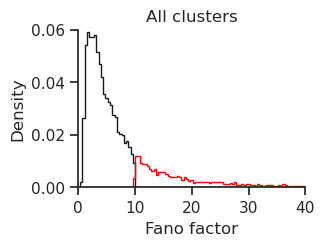

In [38]:
subjects = ['000', '007', '009']
all_fano = []

# Plot each subject separately
for s in subjects:
    fano_subject = get_fano_subject(s)
    # plot_fano_dist(fano_subject)
    # plt.title(f'Subject {s}')
    all_fano.append(fano_subject)

# Plot all subjects together
plot_fano_dist(np.concatenate(all_fano))
plt.title('All clusters')
plt.ylim(0, 0.06)

## M2 vs sub M2

In [12]:
def get_cluster_info_subject(subject):
    """
    Compute Fano factors for all sessions of a subject.
    """

    folder_parent = Path('/archive/mouse/Alexis ephys/spike_sorting') / subject
    ephys_ids = get_ephys_sessions(subject)

    error_sessions = []
    df = pd.DataFrame()

    for i, session_id in enumerate(ephys_ids):
        folder_child = folder_parent / session_id / 'phy2'
        try:
            print(f'Processing session {i + 1}/{len(ephys_ids)}: {session_id}...')
            cluster_info = pd.read_csv(folder_child / 'cluster_info.tsv', sep='\t')
            cluster_info['subject'] = subject
            cluster_info['session'] = session_id
            df = pd.concat([df, cluster_info], ignore_index=True)

        except Exception as e:
            print(f'An error occurred in session {session_id}: {e}')
            error_sessions.append(session_id)
            continue

    return df

In [13]:
def plot_depth_dist(all_cluster_info):

    # Depth is referenced from the probe tip (0). Invert it to get depth from the surface
    surface = all_cluster_info.depth.max()  # mm
    all_cluster_info['depth_inverted'] = surface - all_cluster_info['depth']

    # Split values
    m2_thickness = 1.5  # mm
    m2_mask = all_cluster_info.depth_inverted <= m2_thickness
    subm2_mask = all_cluster_info.depth_inverted > m2_thickness
    weights = np.ones_like(all_cluster_info.depth) / len(all_cluster_info)

    # Plot population histogram
    figsize = fig_size(n_cols=2)
    plt.figure(figsize=figsize, constrained_layout=True)
    bins = np.linspace(0, surface, 100)
    plt.hist(all_cluster_info.depth_inverted[m2_mask], bins=bins,  weights=weights[m2_mask], histtype='step', color='tab:gray', label='M2')
    plt.hist(all_cluster_info.depth_inverted[subm2_mask], bins=bins, weights=weights[subm2_mask], histtype='step', color='tab:pink', label = 'sub M2')
    plt.xlim(0, 4)
    plt.xlabel('Depth (mm)')
    plt.ylabel('Density')
    plt.legend(frameon=False)
    sns.despine()

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/4: 000_2024-07-08_14-58-57...
Processing session 2/4: 000_2024-07-10_14-32-41...
Processing session 3/4: 000_2024-07-11_14-50-25...
An error occurred in session 000_2024-07-11_14-50-25: [Errno 2] No such file or directory: '/archive/mouse/Alexis ephys/spike_sorting/000/000_2024-07-11_14-50-25/phy2/cluster_info.tsv'
Processing session 4/4: 000_2024-07-12_15-42-10...
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-07_13-20-29', '007_2024-07-08_12-20-29', '007_2024-07-09_12-10-57', '007_2024-07-10_12-03-35', '007_2024-07-11_12-39-21', '007_2024-07-12_1

Text(0.5, 1.0, 'All clusters')

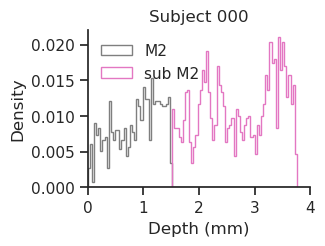

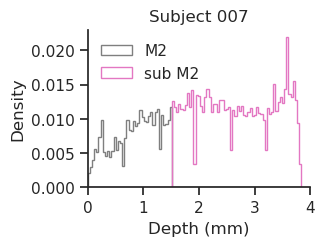

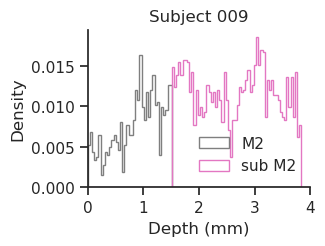

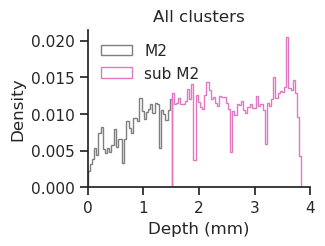

In [19]:
subjects = ['000', '007', '009']
all_cluster_info = pd.DataFrame()

for s in subjects:
    df_cluster_info_subject = get_cluster_info_subject(s)
    df_cluster_info_subject['depth'] = df_cluster_info_subject['depth'] / 1000  # Convert from um to mm
    plot_depth_dist(df_cluster_info_subject)
    plt.title(f'Subject {s}')
    all_cluster_info = pd.concat([all_cluster_info, df_cluster_info_subject], ignore_index=True)

plot_depth_dist(all_cluster_info)
plt.title('All clusters')

Text(0.5, 1.0, 'All clusters')

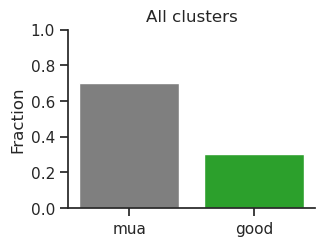

In [18]:
# Count clusters per group
all_cluster_info = all_cluster_info[all_cluster_info['group'].isin(['good', 'mua'])]
counts = all_cluster_info['group'].value_counts()
fractions = counts / counts.sum()

# Bar plot
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plt.bar(fractions.index, fractions.values, color=['tab:gray', 'tab:green'])
plt.ylim(0, 1)
plt.ylabel('Fraction')
sns.despine()
plt.title('All clusters')

# Plot example units

In [ ]:
# subject = '007'
# ephys_id = '007_2024-06-24_17-47-22'
# preprocessed = preprocess(ephys_id)
# cluster_info = preprocessed.cluster_info
# df_spikes = preprocessed.df_spikes
# df_ttl = preprocessed.df_ttl
# df_behavior = preprocessed.df_behavior
# # disengagement = find_disengaged(df_behavior, threshold=0.5, min_trial=200, win_len=20, plot=False)

In [4]:
group = 'good'

# Slice out disengaged trials (based on accuracy)
df_behavior = df_behavior[df_behavior.Trial < disengagement]
df_ttl = df_ttl.iloc[:len(df_behavior)]

if group in ['good', 'mua']:
    clusters = cluster_info[cluster_info.group == group].cluster_id
elif group is None:
    clusters = cluster_info.cluster_id  # All

align = 'stim'
time_win = [-1, 3]
bin_size = 0.1

In [ ]:
figsize = fig_size(n_cols=0, ratio=None)  # A4 size in inches without margins
figsize = (figsize[1] - 1, figsize[0])
figsize

In [ ]:
# clusters = [93, 585, 218, 471]
# for cluster in clusters:
#     df_cluster = df_spikes[df_spikes.cluster == cluster]
#     cluster_report(df_cluster, cluster_info, df_ttl, df_behavior, align=align, time_win=time_win, bin_size=bin_size, save=False)

# Save all notebook's figures

In [ ]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files('notebook.ipynb')

In [5]:
event='StimStart'
# Convert string of lists back to lists
try:
    df_behavior["Port1In"] = df_behavior["Port1In"].apply(ast.literal_eval)
    df_behavior["Port2In"] = df_behavior["Port2In"].apply(ast.literal_eval)
except ValueError:
    # print('Port1In or Port2In are already lists')
    pass

licks_left = df_behavior.Port1In.copy()
licks_right = df_behavior.Port2In.copy()
for trial in range(len(df_behavior)):
    licks_left[trial] = [x - df_behavior[event].iloc[trial] for x in licks_left[trial]]  # Left
    licks_right[trial] = [x - df_behavior[event].iloc[trial] for x in licks_right[trial]]  # Right

In [7]:
indexes = get_trial_indexes(df_behavior, condition='stimulus')
left_trials = indexes[0]
right_trials = indexes[1]

In [9]:
bins, left_psth = compute_psth(licks_left, time_win=[-1, 3], bin_size=0.1)
bins, right_psth = compute_psth(licks_right, time_win=[-1, 3], bin_size=0.1)

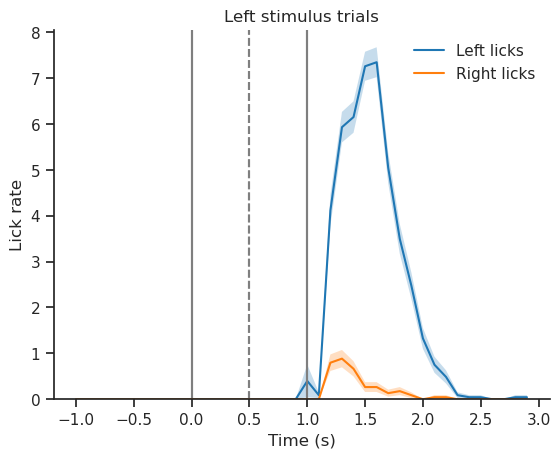

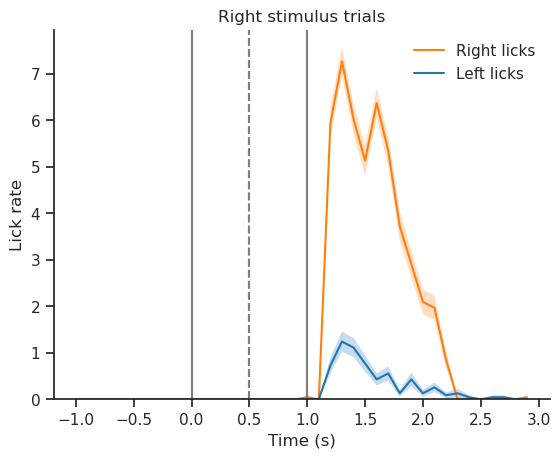

In [24]:
# Left trials
fig, ax = plt.subplots(1, 1)
plot_psth(bins, left_psth[left_trials], bin_size=0.1, color='tab:blue', label='Left licks', ax=ax)
plot_psth(bins, right_psth[left_trials], bin_size=0.1, color='tab:orange', label='Right licks', ax=ax)
plt.title('Left stimulus trials')
sns.despine()
plt.ylabel('Lick rate')
plt.legend(frameon=False)

# Right trials
fig, ax = plt.subplots(1, 1)
plot_psth(bins, right_psth[right_trials], bin_size=0.1, color='tab:orange', label='Right licks', ax=ax)
plot_psth(bins, left_psth[right_trials], bin_size=0.1, color='tab:blue', label='Left licks', ax=ax)
plt.title('Right stimulus trials')
sns.despine()
plt.ylabel('Lick rate')
plt.legend(frameon=False)